# Lab 4.1: Time-Series Feature Engineering

**Name:** Zubair Moeen  
**Reg Number:** 22jzele0463  
**Lab:** Machine Learning Lab  
**Lab Supervisor:** Engr.Irshad Ullah  
**University:** UET Peshawar - Campus Nowshera 

## Lab Overview
This notebook performs feature engineering on the AEP time-series dataset after adding holiday information. The code extracts datetime-based features, creates weekend and day-night indicators, adds seasonal columns, renames columns, reorders the dataset, and saves the final feature-engineered CSV file.

## Learning Objectives
- Load the AEP dataset containing holiday information.
- Extract useful datetime features such as hour, month, week, weekday, quarter, and year day.
- Create binary features for weekend, day-night, and seasons.
- Prepare and save the final feature-engineered dataset for further machine learning work.


## Section 1: Library Import and Dataset Loading
This section imports Pandas and NumPy, then loads the AEP dataset after holiday information has already been introduced.


In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv(r'Z:\University\8th Semester\ML Lab\Lab 4\4_AEP_Introducing_holidays.csv',  parse_dates=['Datetime'])
df.head()

,Datetime,AEP_MW,Date,Holiday
0,2004-10-01 01:00:00,12379.0,2004-10-01,0
1,2004-10-01 02:00:00,11935.0,2004-10-01,0
2,2004-10-01 03:00:00,11692.0,2004-10-01,0
3,2004-10-01 04:00:00,11597.0,2004-10-01,0
4,2004-10-01 05:00:00,11681.0,2004-10-01,0


In [4]:
df['Hour']=df['Datetime'].dt.hour
df['Month']=df['Datetime'].dt.month
df['Day_Of_Week']=df['Datetime'].dt.weekday
df["Week"] = df["Datetime"].dt.isocalendar().week
df['yearday'] = df['Datetime'].dt.dayofyear
df['quarter'] = df['Datetime'].dt.quarter
df['weekend']=(df['Day_Of_Week']>=5).astype("int")
df['day_night']=((df['Hour']>=8) & (df['Hour']<=16)).astype("int")
df.head()

,Datetime,AEP_MW,Date,Holiday,Hour,Month,Day_Of_Week,Week,yearday,quarter,weekend,day_night
0,2004-10-01 01:00:00,12379.0,2004-10-01,0,1,10,4,40,275,4,0,0
1,2004-10-01 02:00:00,11935.0,2004-10-01,0,2,10,4,40,275,4,0,0
2,2004-10-01 03:00:00,11692.0,2004-10-01,0,3,10,4,40,275,4,0,0
3,2004-10-01 04:00:00,11597.0,2004-10-01,0,4,10,4,40,275,4,0,0
4,2004-10-01 05:00:00,11681.0,2004-10-01,0,5,10,4,40,275,4,0,0


# Adding seasons
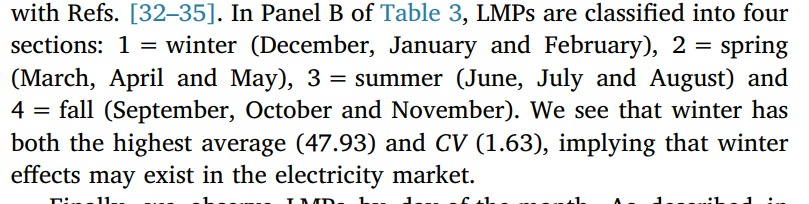

## Section 2: Date and Time Feature Extraction
The following cells extract important features from the Datetime column. These features help machine learning models understand daily, weekly, monthly, and seasonal patterns.


In [5]:
df['winter']= ( (df['Month'] == 12) | (df['Month'] ==1) | (df['Month'] ==2))*1
df['spring']= ( (df['Month'] == 3) | (df['Month'] ==4) | (df['Month'] ==5))*1
df['summer']= ( (df['Month'] == 6) | (df['Month'] ==7) | (df['Month'] ==8))*1
df['fall']=   ( (df['Month'] == 9) | (df['Month'] ==10) | (df['Month'] ==11))*1
df.tail()

,Datetime,AEP_MW,Date,Holiday,Hour,Month,Day_Of_Week,Week,yearday,quarter,weekend,day_night,winter,spring,summer,fall
121291,2018-08-02 20:00:00,17673.0,2018-08-02,0,20,8,3,31,214,3,0,0,0,0,1,0
121292,2018-08-02 21:00:00,17303.0,2018-08-02,0,21,8,3,31,214,3,0,0,0,0,1,0
121293,2018-08-02 22:00:00,17001.0,2018-08-02,0,22,8,3,31,214,3,0,0,0,0,1,0
121294,2018-08-02 23:00:00,15964.0,2018-08-02,0,23,8,3,31,214,3,0,0,0,0,1,0
121295,2018-08-03 00:00:00,14809.0,2018-08-03,0,0,8,4,31,215,3,0,0,0,0,1,0


In [6]:
df.rename(columns={'AEP_MW': 'aep', 'yearday': 'year_day','Week':'week_no',
                   'Holiday':'holiday','quarter':'quarter','day_night':'day_night','weekend':'weekend',
                   'Hour':'hour','Month':'month','Day_Of_Week':'day_of_week'}, inplace=True)
df.head()

,Datetime,aep,Date,holiday,hour,month,day_of_week,week_no,year_day,quarter,weekend,day_night,winter,spring,summer,fall
0,2004-10-01 01:00:00,12379.0,2004-10-01,0,1,10,4,40,275,4,0,0,0,0,0,1
1,2004-10-01 02:00:00,11935.0,2004-10-01,0,2,10,4,40,275,4,0,0,0,0,0,1
2,2004-10-01 03:00:00,11692.0,2004-10-01,0,3,10,4,40,275,4,0,0,0,0,0,1
3,2004-10-01 04:00:00,11597.0,2004-10-01,0,4,10,4,40,275,4,0,0,0,0,0,1
4,2004-10-01 05:00:00,11681.0,2004-10-01,0,5,10,4,40,275,4,0,0,0,0,0,1


In [7]:
df = df.reindex(columns=['Datetime','aep', 'year_day','holiday','weekend','winter','spring','summer','fall','hour','month','day_of_week'])
df.head()

,Datetime,aep,year_day,holiday,weekend,winter,spring,summer,fall,hour,month,day_of_week
0,2004-10-01 01:00:00,12379.0,275,0,0,0,0,0,1,1,10,4
1,2004-10-01 02:00:00,11935.0,275,0,0,0,0,0,1,2,10,4
2,2004-10-01 03:00:00,11692.0,275,0,0,0,0,0,1,3,10,4
3,2004-10-01 04:00:00,11597.0,275,0,0,0,0,0,1,4,10,4
4,2004-10-01 05:00:00,11681.0,275,0,0,0,0,0,1,5,10,4


In [8]:
df.to_csv(r'Z:\University\8th Semester\ML Lab\Lab 4\5_features_extracted.csv', index=False)

## Section 3: Seasonal Features and Final Dataset Export
This section creates seasonal columns, renames variables into a cleaner format, arranges the final column order, and saves the feature-engineered dataset.


In [9]:
df.isnull().sum()

Datetime         0
aep            666
year_day         0
holiday          0
weekend          0
winter           0
spring           0
summer           0
fall             0
hour             0
month            0
day_of_week      0
dtype: int64

In [10]:
df['hour'].value_counts().reindex([0,22, 23, 24], fill_value=0)

hour
0     5054
22    5054
23    5054
24       0
Name: count, dtype: int64

## Final Conclusion
In this lab, new time-based and seasonal features were extracted from the AEP dataset. The final dataset was saved for correlation analysis, scaling, and model training in later labs.

